<a href="https://colab.research.google.com/github/SakshyamAryal077/BASELINE-MODEL-ECG/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
X_train = np.load("X_train_smote.npy")
X_test = np.load("X_testsmall.npy")
y_train = np.load("y_train_smote.npy")
y_test = np.load("y_testsmall.npy")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (108400, 360)
X_test shape: (6753, 360, 1)
y_train shape: (108400,)
y_test shape: (6753,)


In [ ]:
if len(X_train.shape) == 2:
    X_train = np.expand_dims(X_train, axis=1)
    X_test = np.expand_dims(X_test, axis=1)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)


New X_train shape: (108400, 1, 360)
New X_test shape: (6753, 1, 360, 1)


In [ ]:
if len(X_train.shape) == 3 and X_train.shape[2] == 1:
    X_train = np.transpose(X_train, (0, 2, 1))
    X_test = np.transpose(X_test, (0, 2, 1))

print("Fixed X_train shape:", X_train.shape)
print("Fixed X_test shape:", X_test.shape)


Fixed X_train shape: (108400, 1, 360)
Fixed X_test shape: (6753, 1, 360, 1)


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


In [ ]:
from torch.utils.data import Dataset

class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
num_classes = len(torch.unique(y_train))

model = BaselineCNN(num_classes=num_classes).to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [ ]:
#this is the focal loss function use this by uncommenting.Comment this while using normal loss function.
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [ ]:
# # Normal loss
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Focal loss
criterion = FocalLoss(alpha=1.0, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, epoch_f1


In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

batch_size = 64

# Fix: Squeeze the extra dimension from X_test if it exists
# X_test currently has shape (num_samples, 1, 360, 1)
# The conv1d layer expects (batch_size, channels, sequence_length), i.e., (64, 1, 360)
if len(X_test.shape) == 4 and X_test.shape[3] == 1:
    X_test = X_test.squeeze(dim=3) # Converts (6753, 1, 360, 1) to (6753, 1, 360)
    print("X_test shape after squeeze:", X_test.shape)

train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   Macro F1: {val_f1:.4f}")
    print("-" * 60)

X_test shape after squeeze: torch.Size([6753, 1, 360])
Epoch [1/10]
Train Loss: 0.6892 | Train Acc: 0.5370 | Train Macro F1: 0.5287
Val   Loss: 0.5664 | Val   Acc: 0.5448 | Val   Macro F1: 0.3960
------------------------------------------------------------
Epoch [2/10]
Train Loss: 0.4310 | Train Acc: 0.7184 | Train Macro F1: 0.7182
Val   Loss: 0.4593 | Val   Acc: 0.6178 | Val   Macro F1: 0.4316
------------------------------------------------------------
Epoch [3/10]
Train Loss: 0.3838 | Train Acc: 0.7457 | Train Macro F1: 0.7457
Val   Loss: 0.4803 | Val   Acc: 0.6061 | Val   Macro F1: 0.4237
------------------------------------------------------------
Epoch [4/10]
Train Loss: 0.3568 | Train Acc: 0.7582 | Train Macro F1: 0.7586
Val   Loss: 0.4527 | Val   Acc: 0.6428 | Val   Macro F1: 0.4520
------------------------------------------------------------
Epoch [5/10]
Train Loss: 0.3362 | Train Acc: 0.7669 | Train Macro F1: 0.7675
Val   Loss: 0.3556 | Val   Acc: 0.7377 | Val   Macro F1: 0.5

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.77      0.19        48
           1       0.96      0.76      0.85      5421
           2       0.67      0.74      0.70       683
           3       0.20      0.74      0.32       167
           4       0.49      0.84      0.62       434

    accuracy                           0.77      6753
   macro avg       0.49      0.77      0.54      6753
weighted avg       0.88      0.77      0.80      6753

Confusion Matrix:
[[  37    8    1    0    2]
 [ 267 4147  235  458  314]
 [  13   86  504   20   60]
 [   0   32    3  124    8]
 [  24   26   13    5  366]]


Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.77      0.19        48
           1       0.96      0.76      0.85      5421
           2       0.67      0.74      0.70       683
           3       0.20      0.74      0.32       167
           4       0.49      0.84      0.62       434

    accuracy                           0.77      6753
   macro avg       0.49      0.77      0.54      6753
weighted avg       0.88      0.77      0.80      6753



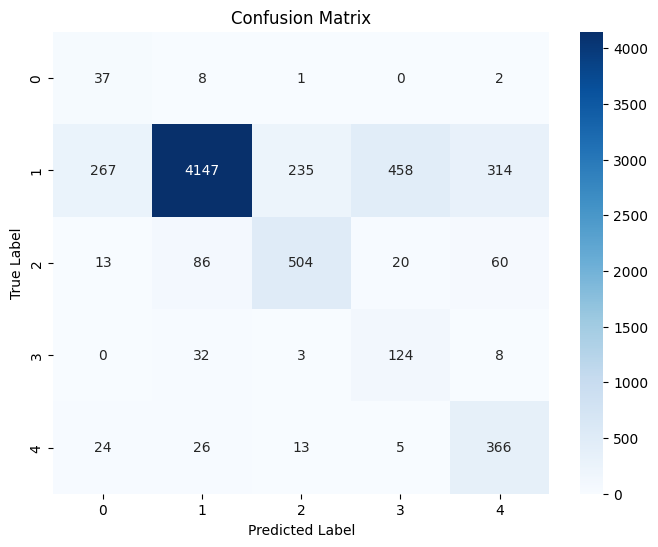

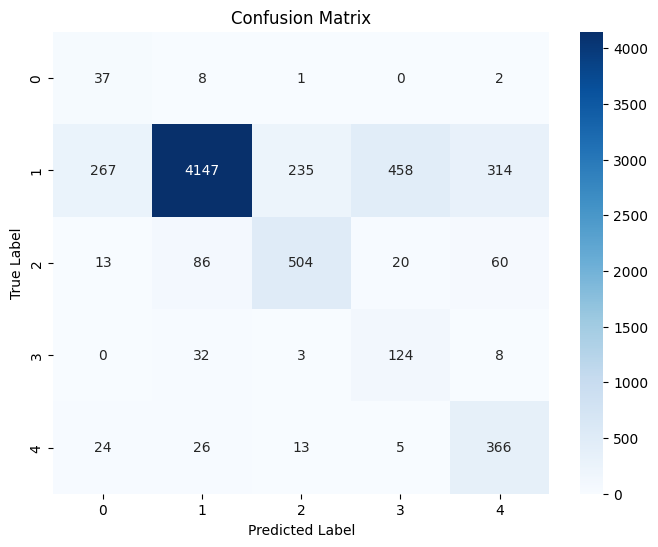

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
